In [1]:
# ============================================================
# CELL 0 — Setup
# Validation Option A: Multi-Grade Comparison
# SARIMA vs LSTM across all 5 tea grades
# ============================================================

import os
os.makedirs('plots/optionA', exist_ok=True)
os.makedirs('results',       exist_ok=True)

print("="*55)
print("   🎓 VALIDATION OPTION A — MULTI-GRADE COMPARISON")
print("="*55)
print()
print("   What this notebook does:")
print("   → Runs SARIMA and LSTM on ALL 5 tea grades")
print("   → Grades: BOP, BOPF, DUST, FNGS, OP")
print("   → Compares results across every grade")
print("   → Produces a final summary table")
print("   → Shows which model is more CONSISTENTLY better")
print()
print("   Why this is stronger than single-grade testing:")
print("   → If LSTM wins on all 5 grades → very strong proof")
print("   → If results are mixed → honest scientific finding")
print("   → Academic standard requires multiple experiments")
print()
print("✅ Folders created!")
print("✅ Ready for Cell 1!")

   🎓 VALIDATION OPTION A — MULTI-GRADE COMPARISON

   What this notebook does:
   → Runs SARIMA and LSTM on ALL 5 tea grades
   → Grades: BOP, BOPF, DUST, FNGS, OP
   → Compares results across every grade
   → Produces a final summary table
   → Shows which model is more CONSISTENTLY better

   Why this is stronger than single-grade testing:
   → If LSTM wins on all 5 grades → very strong proof
   → If results are mixed → honest scientific finding
   → Academic standard requires multiple experiments

✅ Folders created!
✅ Ready for Cell 1!


In [2]:
# ============================================================
# CELL 1 — Import All Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

# LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

plt.style.use('seaborn-v0_8-darkgrid')

print("="*50)
print("   ✅ ALL LIBRARIES IMPORTED!")
print("="*50)
print(f"   TensorFlow : {tf.__version__}")
print(f"   pmdarima   : {pm.__version__}")
print(f"   pandas     : {pd.__version__}")
print("="*50)
print("✅ Ready for Cell 2!")

   ✅ ALL LIBRARIES IMPORTED!
   TensorFlow : 2.21.0
   pmdarima   : 2.1.1
   pandas     : 3.0.3
✅ Ready for Cell 2!


In [3]:
# ============================================================
# CELL 2 — Load Dataset and Define All 5 Grades
# ============================================================

df = pd.read_csv('data/tea_demand_timeseries.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("="*55)
print("   📊 DATASET LOADED")
print("="*55)
print(f"   Total rows  : {len(df):,}")
print(f"   Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print()

# All 5 tea grades to test
ALL_GRADES = ['BOP', 'BOPF', 'DUST', 'FNGS', 'OP']

# Grade descriptions (for reports)
GRADE_DESC = {
    'BOP':  'Broken Orange Pekoe       (highest volume)',
    'BOPF': 'Broken Orange Pekoe Fine  (medium volume)',
    'DUST': 'Dust                      (medium volume)',
    'FNGS': 'Fannings                  (lower volume)',
    'OP':   'Orange Pekoe              (premium/lowest volume)'
}

# Settings
TEST_DAYS = 30
LOOK_BACK = 30

print("   Grades to test:")
for g in ALL_GRADES:
    grade_data = df[df['TeaGrade'] == g]
    avg_demand = grade_data['DemandKg'].mean()
    print(f"   {g:<6} → {GRADE_DESC[g]}  |  avg={avg_demand:.0f} kg/day")

print()
print(f"   Test window  : {TEST_DAYS} days")
print(f"   LSTM lookback: {LOOK_BACK} days")
print()
print("✅ Ready for Cell 3!")

   📊 DATASET LOADED
   Total rows  : 5,475
   Date range  : 2021-01-01 → 2023-12-31

   Grades to test:
   BOP    → Broken Orange Pekoe       (highest volume)  |  avg=319 kg/day
   BOPF   → Broken Orange Pekoe Fine  (medium volume)  |  avg=279 kg/day
   DUST   → Dust                      (medium volume)  |  avg=238 kg/day
   FNGS   → Fannings                  (lower volume)  |  avg=179 kg/day
   OP     → Orange Pekoe              (premium/lowest volume)  |  avg=120 kg/day

   Test window  : 30 days
   LSTM lookback: 30 days

✅ Ready for Cell 3!


In [4]:
# ============================================================
# CELL 3 — Define Helper Functions
#
# We define all functions here ONCE
# Then reuse them for each of the 5 grades
# This keeps the code clean and avoids repetition
# ============================================================

def get_metrics(actual, predicted, model_name, grade):
    """Calculate MAE, RMSE, MAPE for a prediction"""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        'Grade':  grade,
        'Model':  model_name,
        'MAE':    round(mae,  3),
        'RMSE':   round(rmse, 3),
        'MAPE':   round(mape, 3)
    }


def run_sarima_for_grade(train_series, test_series, grade):
    """
    Run SARIMA on one grade's time series
    Returns: predictions array and metrics dict
    """
    print(f"      🔄 Running auto_arima for {grade}...")

    try:
        # Auto-find best SARIMA parameters
        auto_model = pm.auto_arima(
            train_series,
            seasonal=True,
            m=7,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            information_criterion='aic',
            trace=False       # Silent mode for multi-grade run
        )

        # Fit the model
        fitted = SARIMAX(
            train_series,
            order=auto_model.order,
            seasonal_order=auto_model.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        # Forecast
        forecast = fitted.forecast(steps=len(test_series))
        forecast = np.array(forecast)

        metrics = get_metrics(
            test_series.values,
            forecast,
            'SARIMA',
            grade
        )

        params_str = f"order={auto_model.order} seasonal={auto_model.seasonal_order}"
        print(f"      ✅ SARIMA done! Params: {params_str}")
        print(f"         MAPE = {metrics['MAPE']:.3f}%")

        return forecast, metrics, auto_model.order, auto_model.seasonal_order

    except Exception as e:
        print(f"      ❌ SARIMA failed for {grade}: {e}")
        return None, None, None, None


def run_lstm_for_grade(full_series, test_days, look_back, grade):
    """
    Run LSTM on one grade's time series
    Returns: predictions array and metrics dict
    """
    print(f"      🔄 Training LSTM for {grade}...")

    try:
        # Scale data
        scaler      = MinMaxScaler(feature_range=(0, 1))
        scaled      = scaler.fit_transform(full_series.values.reshape(-1, 1))

        # Build sequences
        X_all, y_all = [], []
        for i in range(look_back, len(scaled)):
            X_all.append(scaled[i - look_back:i, 0])
            y_all.append(scaled[i, 0])
        X_all = np.array(X_all)
        y_all = np.array(y_all)

        # Split
        split    = len(X_all) - test_days
        X_train  = X_all[:split].reshape(-1, look_back, 1)
        X_test   = X_all[split:].reshape(-1, look_back, 1)
        y_train  = y_all[:split]
        y_test   = y_all[split:]

        # Build model
        tf.keras.backend.clear_session()
        model = Sequential([
            LSTM(64, return_sequences=True,
                 input_shape=(look_back, 1)),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

        # Train
        early_stop = EarlyStopping(
            monitor='val_loss', patience=12,
            restore_best_weights=True, verbose=0
        )
        model.fit(
            X_train, y_train,
            epochs=80,
            batch_size=16,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0           # Silent mode
        )

        # Predict
        pred_scaled  = model.predict(X_test, verbose=0)
        pred_kg      = scaler.inverse_transform(pred_scaled).flatten()
        actual_kg    = scaler.inverse_transform(
                           y_test.reshape(-1,1)
                       ).flatten()

        metrics = get_metrics(actual_kg, pred_kg, 'LSTM', grade)

        print(f"      ✅ LSTM done!")
        print(f"         MAPE = {metrics['MAPE']:.3f}%")

        return pred_kg, actual_kg, metrics

    except Exception as e:
        print(f"      ❌ LSTM failed for {grade}: {e}")
        return None, None, None


print("="*50)
print("   ✅ ALL HELPER FUNCTIONS DEFINED!")
print("="*50)
print()
print("   Functions ready:")
print("   ✅ get_metrics()          — calculates MAE/RMSE/MAPE")
print("   ✅ run_sarima_for_grade() — runs SARIMA on any grade")
print("   ✅ run_lstm_for_grade()   — runs LSTM on any grade")
print()
print("✅ Ready for Cell 4 (The Main Loop)!")

   ✅ ALL HELPER FUNCTIONS DEFINED!

   Functions ready:
   ✅ get_metrics()          — calculates MAE/RMSE/MAPE
   ✅ run_sarima_for_grade() — runs SARIMA on any grade
   ✅ run_lstm_for_grade()   — runs LSTM on any grade

✅ Ready for Cell 4 (The Main Loop)!


In [5]:
# ============================================================
# CELL 4 — RUN SARIMA AND LSTM ON ALL 5 GRADES
#
# ⏳ THIS WILL TAKE 15-30 MINUTES TOTAL
#    Each grade runs SARIMA (2-4 min) + LSTM (3-5 min)
#    5 grades × ~7 min = ~35 min
#
# DO NOT CLOSE THE BROWSER WHILE THIS RUNS
# Just let it run and wait
# You will see progress printed for each grade
# ============================================================

# Storage for all results
all_results        = []    # Metrics for every grade + model
grade_forecasts    = {}    # Forecast arrays for plotting

print("="*60)
print("   🚀 STARTING MULTI-GRADE COMPARISON")
print("="*60)
print()
print("   Running SARIMA and LSTM on 5 tea grades...")
print(f"   Grades: {ALL_GRADES}")
print()
print("   ⏳ Estimated time: 20-35 minutes total")
print("   ⚠️  Do NOT close this browser tab")
print("="*60)
print()

# ---- Loop through all 5 grades ----
for grade_num, grade in enumerate(ALL_GRADES, 1):

    print(f"{'='*55}")
    print(f"   GRADE {grade_num}/5 — {grade}  ({GRADE_DESC[grade]})")
    print(f"{'='*55}")

    # --- Prepare this grade's time series ---
    grade_df = df[df['TeaGrade'] == grade].copy()
    grade_df = grade_df.sort_values('Date').set_index('Date')
    grade_df.index.freq = 'D'
    ts_grade = grade_df['DemandKg']

    print(f"   Data: {len(ts_grade)} days | "
          f"avg={ts_grade.mean():.1f} kg | "
          f"min={ts_grade.min():.1f} kg | "
          f"max={ts_grade.max():.1f} kg")
    print()

    # --- Split ---
    train_g = ts_grade.iloc[:-TEST_DAYS]
    test_g  = ts_grade.iloc[-TEST_DAYS:]
    test_dates_g = test_g.index

    print(f"   Training: {len(train_g)} days "
          f"({train_g.index[0].date()} → {train_g.index[-1].date()})")
    print(f"   Testing : {len(test_g)} days  "
          f"({test_g.index[0].date()}  → {test_g.index[-1].date()})")
    print()

    # --- Run SARIMA ---
    sarima_pred, sarima_metrics, sarima_order, sarima_seasonal = \
        run_sarima_for_grade(train_g, test_g, grade)

    print()

    # --- Run LSTM ---
    lstm_pred, lstm_actual, lstm_metrics = \
        run_lstm_for_grade(ts_grade, TEST_DAYS, LOOK_BACK, grade)

    print()

    # --- Store results ---
    if sarima_metrics:
        all_results.append(sarima_metrics)

    if lstm_metrics:
        all_results.append(lstm_metrics)

    # --- Store for plotting ---
    if sarima_pred is not None and lstm_pred is not None:
        grade_forecasts[grade] = {
            'test_dates':    test_dates_g,
            'actual':        test_g.values,
            'sarima_pred':   sarima_pred,
            'lstm_pred':     lstm_pred,
            'lstm_actual':   lstm_actual,
            'sarima_mape':   sarima_metrics['MAPE'],
            'lstm_mape':     lstm_metrics['MAPE'],
            'sarima_order':  sarima_order,
        }

    # --- Quick winner summary for this grade ---
    if sarima_metrics and lstm_metrics:
        winner = 'LSTM' if lstm_metrics['MAPE'] < sarima_metrics['MAPE'] else 'SARIMA'
        diff   = abs(sarima_metrics['MAPE'] - lstm_metrics['MAPE'])
        print(f"   🏆 {grade} WINNER: {winner}  "
              f"(MAPE diff = {diff:.2f}%)")

    print()

print("="*60)
print("   ✅ ALL 5 GRADES COMPLETE!")
print("="*60)
print()
print("   Converting results to DataFrame...")

# Convert all results to a DataFrame
results_df = pd.DataFrame(all_results)
print(results_df.to_string())

# Save results to CSV
results_df.to_csv('results/optionA_all_grades_results.csv', index=False)
print()
print("✅ Results saved → results/optionA_all_grades_results.csv")
print("✅ Ready for Cell 5!")

   🚀 STARTING MULTI-GRADE COMPARISON

   Running SARIMA and LSTM on 5 tea grades...
   Grades: ['BOP', 'BOPF', 'DUST', 'FNGS', 'OP']

   ⏳ Estimated time: 20-35 minutes total
   ⚠️  Do NOT close this browser tab

   GRADE 1/5 — BOP  (Broken Orange Pekoe       (highest volume))
   Data: 1095 days | avg=319.0 kg | min=108.8 kg | max=495.5 kg

   Training: 1065 days (2021-01-01 → 2023-12-01)
   Testing : 30 days  (2023-12-02  → 2023-12-31)

      🔄 Running auto_arima for BOP...
      ✅ SARIMA done! Params: order=(0, 1, 1) seasonal=(2, 0, 0, 7)
         MAPE = 15.562%

      🔄 Training LSTM for BOP...

      ✅ LSTM done!
         MAPE = 7.477%

   🏆 BOP WINNER: LSTM  (MAPE diff = 8.08%)

   GRADE 2/5 — BOPF  (Broken Orange Pekoe Fine  (medium volume))
   Data: 1095 days | avg=278.6 kg | min=111.5 kg | max=424.3 kg

   Training: 1065 days (2021-01-01 → 2023-12-01)
   Testing : 30 days  (2023-12-02  → 2023-12-31)

      🔄 Running auto_arima for BOPF...
      ✅ SARIMA done! Params: order=(5, 

In [6]:
# ============================================================
# CELL 5 — Build and Display Results Summary Table
# ============================================================

print("="*70)
print("   📊 OPTION A — COMPLETE RESULTS TABLE")
print("="*70)

# Pivot table: grades as rows, models as columns
pivot = results_df.pivot(index='Grade', columns='Model', values='MAPE')
pivot = pivot.reindex(ALL_GRADES)
pivot.columns.name = None

# Add winner column
pivot['Winner']    = pivot.apply(
    lambda row: '🏆 LSTM' if row['LSTM'] < row['SARIMA'] else '🏆 SARIMA',
    axis=1
)

# Add difference column
pivot['MAPE Diff'] = abs(pivot['LSTM'] - pivot['SARIMA']).round(3)
pivot['LSTM Better By'] = (pivot['SARIMA'] - pivot['LSTM']).round(3)

print()
print(f"   {'Grade':<8} {'SARIMA MAPE':>14} {'LSTM MAPE':>12} {'Winner':>12} {'Diff':>8}")
print(f"   {'─'*60}")
for grade in ALL_GRADES:
    s_mape = pivot.loc[grade, 'SARIMA']
    l_mape = pivot.loc[grade, 'LSTM']
    winner = pivot.loc[grade, 'Winner']
    diff   = pivot.loc[grade, 'MAPE Diff']
    # MAPE rating
    l_rating = '🌟' if l_mape < 10 else ('✅' if l_mape < 20 else '⚠️')
    s_rating = '🌟' if s_mape < 10 else ('✅' if s_mape < 20 else '⚠️')
    print(f"   {grade:<8} {s_mape:>10.3f}%{s_rating}  "
          f"{l_mape:>10.3f}%{l_rating}  {winner:>12}  {diff:>6.3f}%")

print(f"   {'─'*60}")

# Count wins
lstm_wins   = sum(1 for g in ALL_GRADES
                  if pivot.loc[g, 'LSTM'] < pivot.loc[g, 'SARIMA'])
sarima_wins = 5 - lstm_wins

print(f"   {'TOTAL WINS':<8} "
      f"{'SARIMA: '+str(sarima_wins)+'/5':>14} "
      f"{'LSTM: '+str(lstm_wins)+'/5':>12}")
print()

# Average MAPE
avg_sarima = results_df[results_df['Model']=='SARIMA']['MAPE'].mean()
avg_lstm   = results_df[results_df['Model']=='LSTM']['MAPE'].mean()
print(f"   Average MAPE across all 5 grades:")
print(f"   SARIMA average : {avg_sarima:.3f}%")
print(f"   LSTM   average : {avg_lstm:.3f}%")
print(f"   Overall winner : {'LSTM 🏆' if avg_lstm < avg_sarima else 'SARIMA 🏆'}")
print()
print("="*70)

# MAE and RMSE table too
print()
print("   Full metrics table (MAE and RMSE):")
full_pivot_mae  = results_df.pivot(
    index='Grade', columns='Model', values='MAE').reindex(ALL_GRADES)
full_pivot_rmse = results_df.pivot(
    index='Grade', columns='Model', values='RMSE').reindex(ALL_GRADES)

print(f"\n   MAE (kg/day) — lower is better:")
print(full_pivot_mae.round(2).to_string())
print(f"\n   RMSE (kg/day) — lower is better:")
print(full_pivot_rmse.round(2).to_string())

print("\n✅ Summary complete! Ready for Cell 6!")

   📊 OPTION A — COMPLETE RESULTS TABLE

   Grade       SARIMA MAPE    LSTM MAPE       Winner     Diff
   ────────────────────────────────────────────────────────────
   BOP          15.562%✅       7.477%🌟        🏆 LSTM   8.085%
   BOPF         17.572%✅       9.846%🌟        🏆 LSTM   7.726%
   DUST         14.542%✅       8.083%🌟        🏆 LSTM   6.459%
   FNGS         12.193%✅       9.403%🌟        🏆 LSTM   2.790%
   OP           19.149%✅       8.331%🌟        🏆 LSTM  10.818%
   ────────────────────────────────────────────────────────────
   TOTAL WINS    SARIMA: 0/5    LSTM: 5/5

   Average MAPE across all 5 grades:
   SARIMA average : 15.804%
   LSTM   average : 8.628%
   Overall winner : LSTM 🏆


   Full metrics table (MAE and RMSE):

   MAE (kg/day) — lower is better:
Model   LSTM  SARIMA
Grade               
BOP    28.61   60.59
BOPF   31.35   48.26
DUST   22.73   39.80
FNGS   19.58   27.61
OP     10.78   25.34

   RMSE (kg/day) — lower is better:
Model   LSTM  SARIMA
Grade            

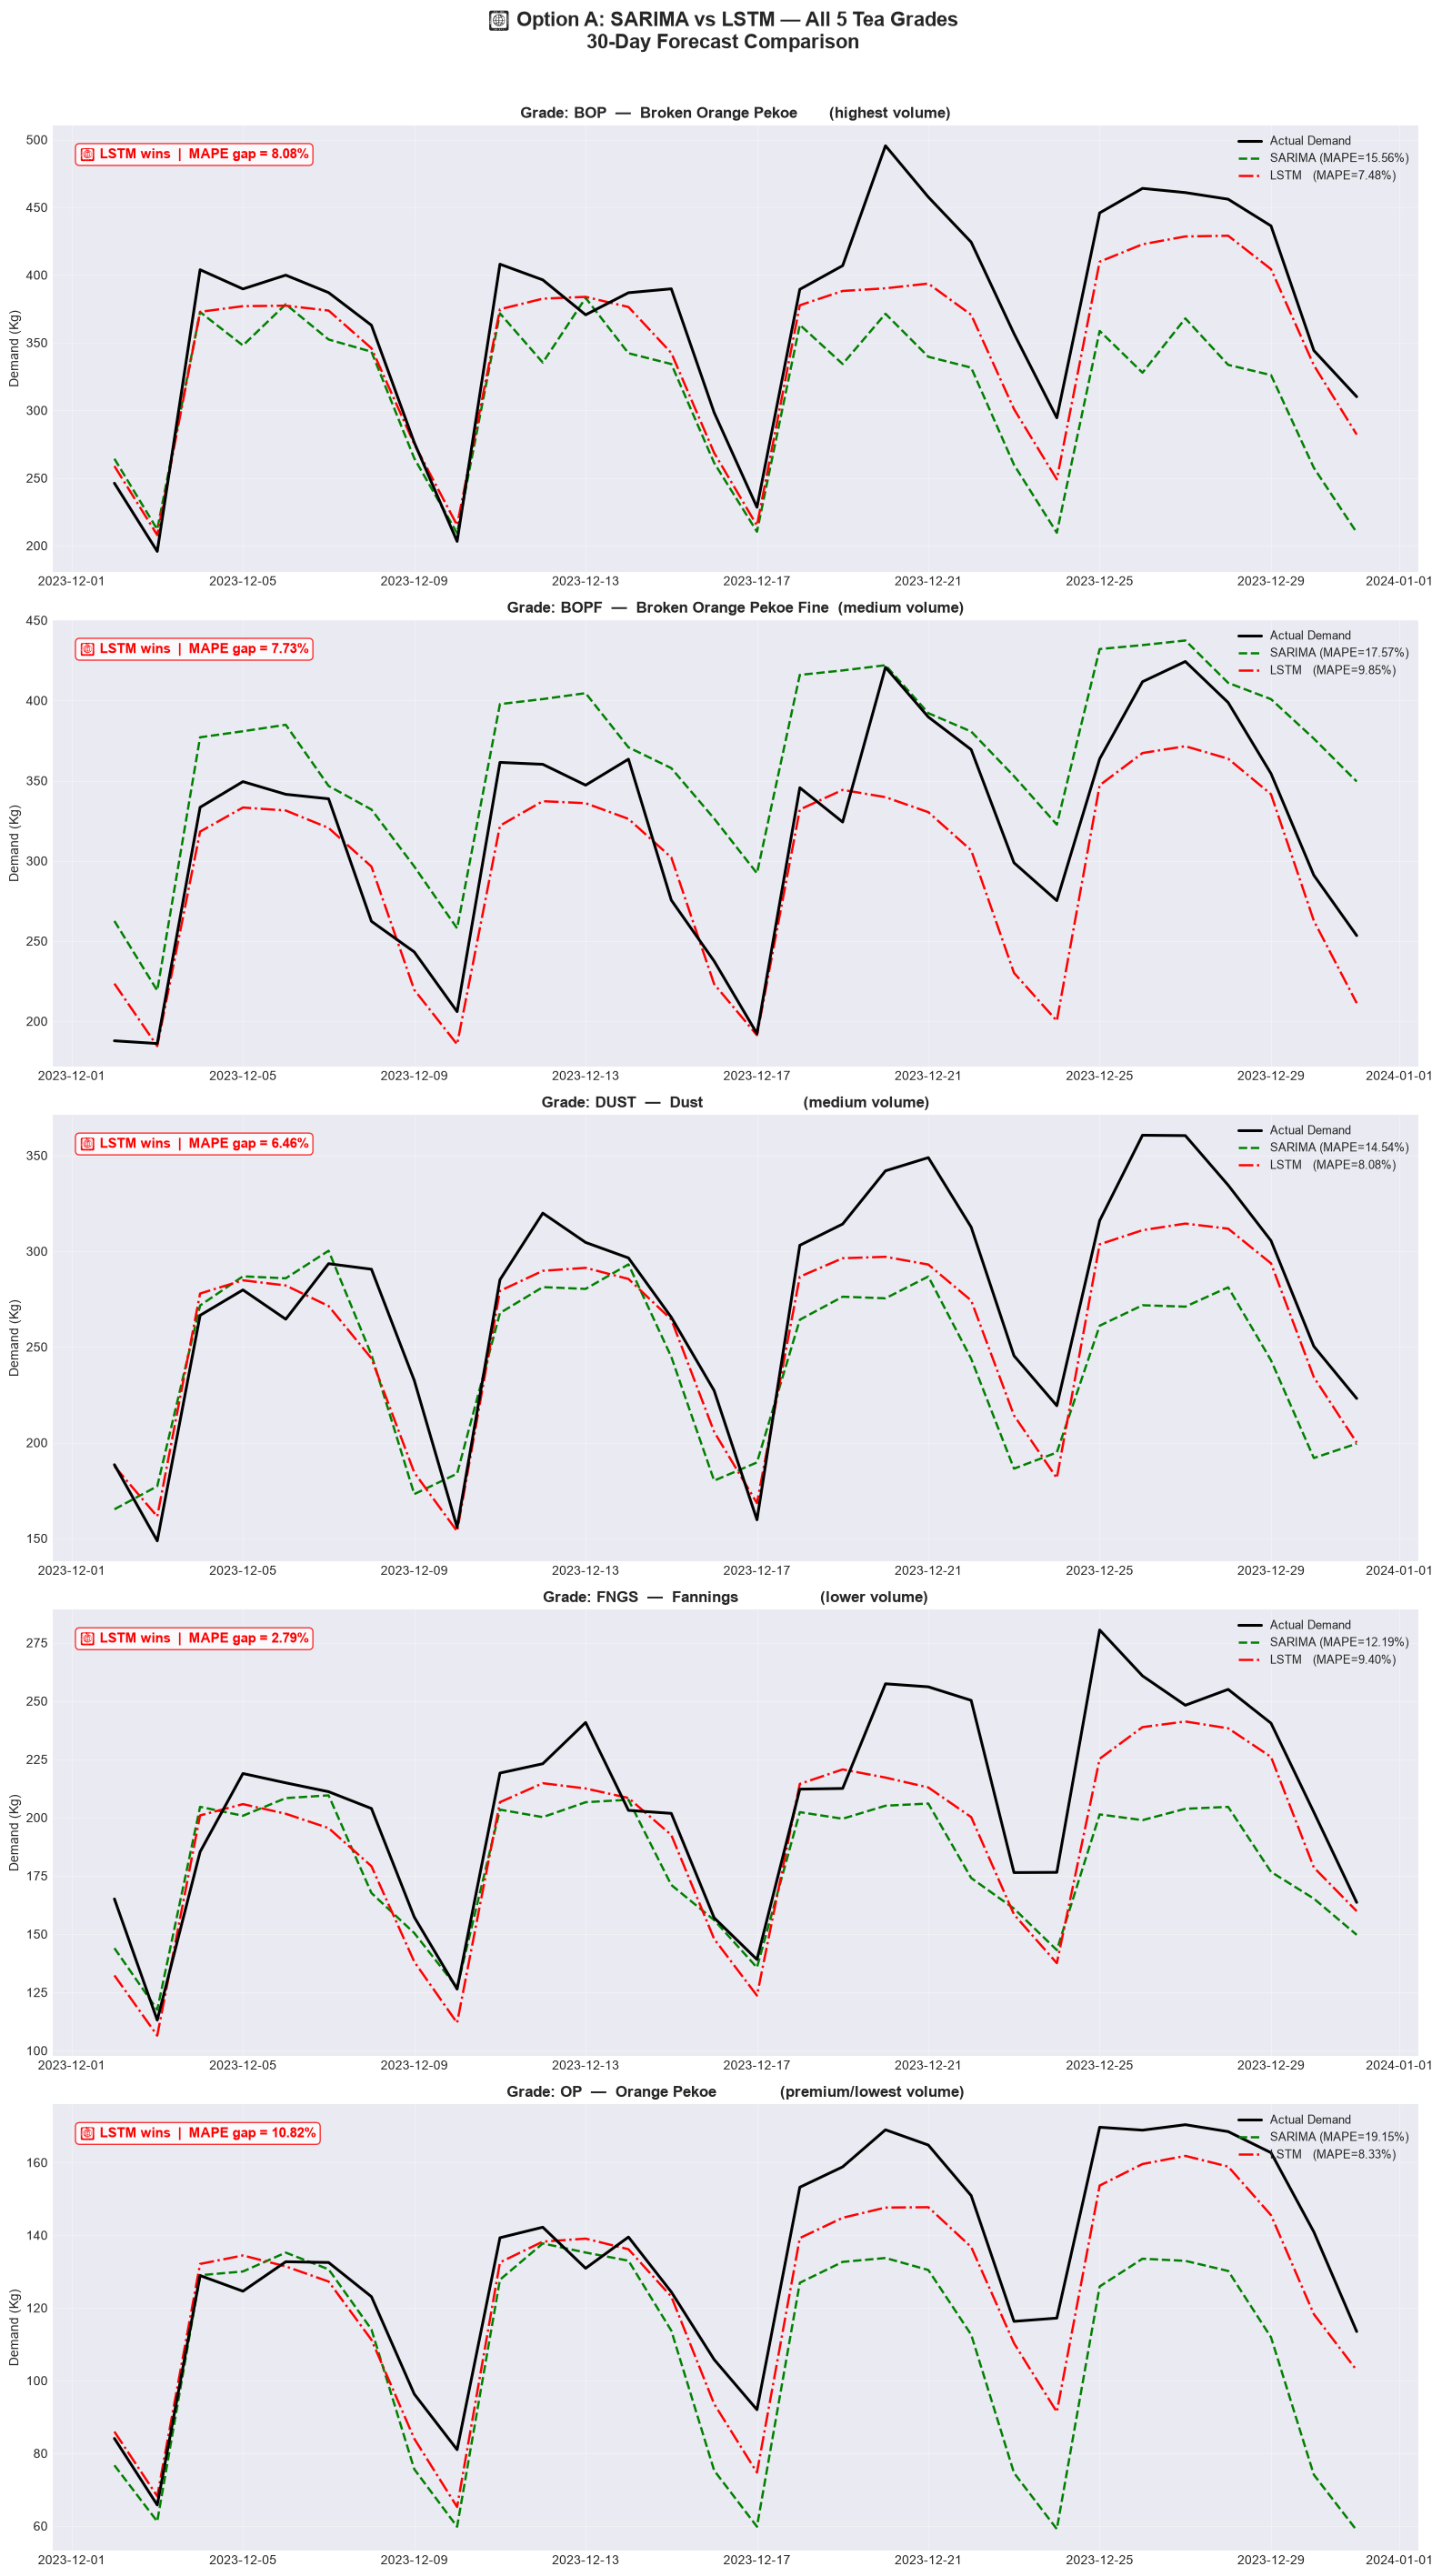

✅ All-grades forecast plot saved!
   → plots/optionA/A01_all_grades_forecasts.png
✅ Ready for Cell 7!


In [7]:
# ============================================================
# CELL 6 — Plot Forecast for Each Grade
# ============================================================

fig, axes = plt.subplots(5, 1, figsize=(16, 28))
fig.suptitle(
    '📊 Option A: SARIMA vs LSTM — All 5 Tea Grades\n'
    '30-Day Forecast Comparison',
    fontsize=16, fontweight='bold', y=1.01
)

for idx, grade in enumerate(ALL_GRADES):
    ax = axes[idx]

    if grade not in grade_forecasts:
        ax.text(0.5, 0.5, f'{grade}: Data not available',
                transform=ax.transAxes, ha='center')
        continue

    gf        = grade_forecasts[grade]
    dates     = gf['test_dates']
    actual    = gf['actual']
    sarima_p  = gf['sarima_pred']
    lstm_p    = gf['lstm_pred']
    s_mape    = gf['sarima_mape']
    l_mape    = gf['lstm_mape']

    winner    = 'LSTM' if l_mape < s_mape else 'SARIMA'
    win_color = 'red' if winner == 'LSTM' else 'green'

    # Plot
    ax.plot(dates, actual,
            color='black', linewidth=2.2,
            label='Actual Demand', zorder=5)
    ax.plot(dates, sarima_p,
            color='green', linewidth=1.8,
            linestyle='--',
            label=f'SARIMA (MAPE={s_mape:.2f}%)')
    ax.plot(dates, lstm_p,
            color='red', linewidth=1.8,
            linestyle='-.',
            label=f'LSTM   (MAPE={l_mape:.2f}%)')

    # Winner badge
    ax.text(0.02, 0.95,
            f'🏆 {winner} wins  |  MAPE gap = {abs(s_mape - l_mape):.2f}%',
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color=win_color,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white',
                      alpha=0.8, edgecolor=win_color))

    ax.set_title(
        f'Grade: {grade}  —  {GRADE_DESC[grade]}',
        fontweight='bold', fontsize=12
    )
    ax.set_ylabel('Demand (Kg)')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/optionA/A01_all_grades_forecasts.png',
            dpi=130, bbox_inches='tight')
plt.show()

print("✅ All-grades forecast plot saved!")
print("   → plots/optionA/A01_all_grades_forecasts.png")
print("✅ Ready for Cell 7!")

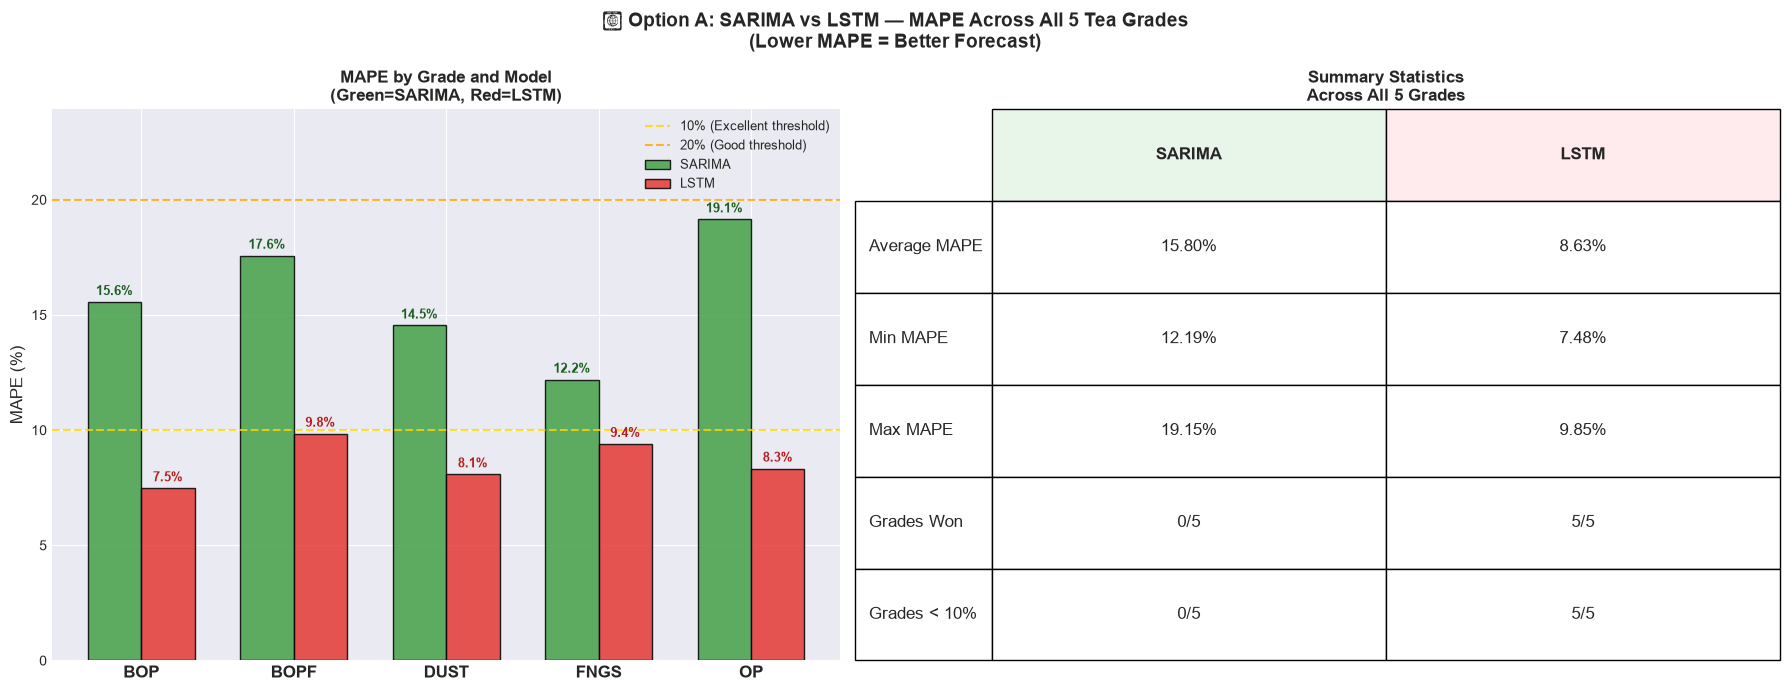

✅ MAPE comparison chart saved!
   → plots/optionA/A02_mape_comparison.png
✅ Ready for Cell 8!


In [8]:
# ============================================================
# CELL 7 — MAPE Comparison Bar Chart Across All Grades
# ============================================================

sarima_mapes = [results_df[(results_df['Grade']==g) &
                            (results_df['Model']=='SARIMA')]['MAPE'].values[0]
                for g in ALL_GRADES]

lstm_mapes   = [results_df[(results_df['Grade']==g) &
                            (results_df['Model']=='LSTM')]['MAPE'].values[0]
                for g in ALL_GRADES]

x     = np.arange(len(ALL_GRADES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    '📊 Option A: SARIMA vs LSTM — MAPE Across All 5 Tea Grades\n'
    '(Lower MAPE = Better Forecast)',
    fontsize=14, fontweight='bold'
)

# ---- Grouped bar chart ----
ax = axes[0]
bars_s = ax.bar(x - width/2, sarima_mapes,
                width, label='SARIMA',
                color='#43A047', alpha=0.85,
                edgecolor='black')
bars_l = ax.bar(x + width/2, lstm_mapes,
                width, label='LSTM',
                color='#E53935', alpha=0.85,
                edgecolor='black')

# Add value labels
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9, fontweight='bold',
            color='#1B5E20')

for bar in bars_l:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9, fontweight='bold',
            color='#B71C1C')

# Reference lines
ax.axhline(y=10, color='gold',    linestyle='--',
           alpha=0.8, linewidth=1.5, label='10% (Excellent threshold)')
ax.axhline(y=20, color='orange',  linestyle='--',
           alpha=0.8, linewidth=1.5, label='20% (Good threshold)')

ax.set_xticks(x)
ax.set_xticklabels(ALL_GRADES, fontsize=12, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE by Grade and Model\n(Green=SARIMA, Red=LSTM)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, max(max(sarima_mapes), max(lstm_mapes)) * 1.25)

# ---- Average MAPE radar/summary ----
ax2 = axes[1]
categories = ALL_GRADES + [ALL_GRADES[0]]  # Close the shape
sarima_vals = sarima_mapes + [sarima_mapes[0]]
lstm_vals   = lstm_mapes   + [lstm_mapes[0]]

# Simple polar/spider is complex — use simple grouped summary instead
avg_data = {
    'Metric': ['Average MAPE', 'Min MAPE', 'Max MAPE',
               'Grades Won', 'Grades < 10%'],
    'SARIMA': [
        f"{np.mean(sarima_mapes):.2f}%",
        f"{np.min(sarima_mapes):.2f}%",
        f"{np.max(sarima_mapes):.2f}%",
        f"{5 - sum(1 for i in range(5) if lstm_mapes[i] < sarima_mapes[i])}/5",
        f"{sum(1 for m in sarima_mapes if m < 10)}/5"
    ],
    'LSTM': [
        f"{np.mean(lstm_mapes):.2f}%",
        f"{np.min(lstm_mapes):.2f}%",
        f"{np.max(lstm_mapes):.2f}%",
        f"{sum(1 for i in range(5) if lstm_mapes[i] < sarima_mapes[i])}/5",
        f"{sum(1 for m in lstm_mapes if m < 10)}/5"
    ]
}
summary_df = pd.DataFrame(avg_data).set_index('Metric')

ax2.axis('off')
table = ax2.table(
    cellText=summary_df.values,
    rowLabels=summary_df.index,
    colLabels=['SARIMA', 'LSTM'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(12)

# Color header
for j in range(2):
    table[0, j].set_facecolor('#E8F5E9' if j == 0 else '#FFEBEE')
    table[0, j].set_text_props(fontweight='bold')

ax2.set_title('Summary Statistics\nAcross All 5 Grades',
              fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('plots/optionA/A02_mape_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ MAPE comparison chart saved!")
print("   → plots/optionA/A02_mape_comparison.png")
print("✅ Ready for Cell 8!")

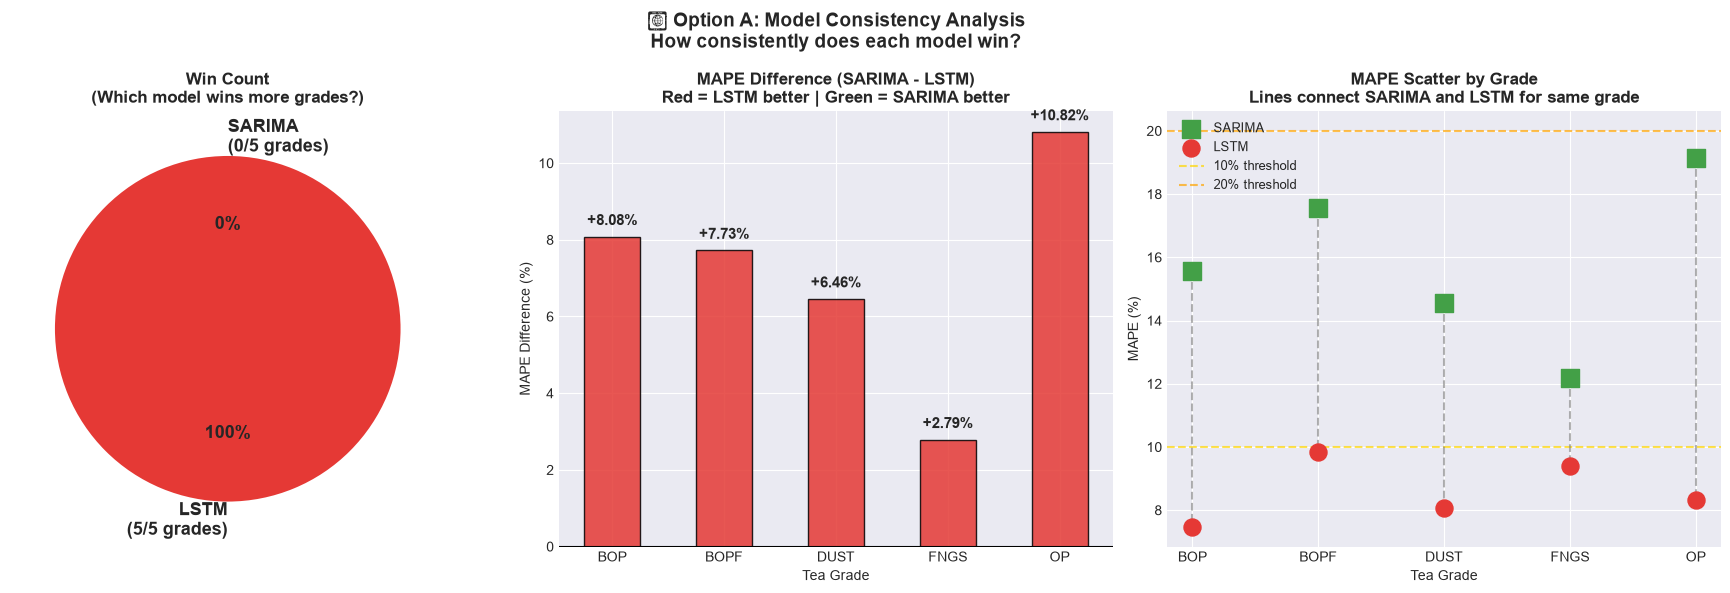

✅ Winner analysis saved!
   → plots/optionA/A03_winner_analysis.png
✅ Ready for Cell 9!


In [9]:
# ============================================================
# CELL 8 — Winner Analysis and Consistency Chart
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    '📊 Option A: Model Consistency Analysis\n'
    'How consistently does each model win?',
    fontsize=14, fontweight='bold'
)

# ---- Chart 1: Win count pie chart ----
lstm_win_count   = sum(1 for i in range(5)
                       if lstm_mapes[i] < sarima_mapes[i])
sarima_win_count = 5 - lstm_win_count

axes[0].pie(
    [sarima_win_count, lstm_win_count],
    labels=[f'SARIMA\n({sarima_win_count}/5 grades)',
            f'LSTM\n({lstm_win_count}/5 grades)'],
    colors=['#43A047', '#E53935'],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 13, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Win Count\n(Which model wins more grades?)',
                  fontweight='bold')

# ---- Chart 2: MAPE improvement (SARIMA - LSTM) ----
improvements = [s - l for s, l in zip(sarima_mapes, lstm_mapes)]
colors_imp   = ['#E53935' if imp > 0 else '#43A047'
                for imp in improvements]

bars = axes[1].bar(ALL_GRADES, improvements,
                   color=colors_imp, edgecolor='black',
                   alpha=0.85, width=0.5)
axes[1].axhline(y=0, color='black', linewidth=1.5)

for bar, val in zip(bars, improvements):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + (0.3 if val >= 0 else -0.8),
        f'{val:+.2f}%',
        ha='center', fontweight='bold', fontsize=11
    )

axes[1].set_title(
    'MAPE Difference (SARIMA - LSTM)\n'
    'Red = LSTM better | Green = SARIMA better',
    fontweight='bold'
)
axes[1].set_ylabel('MAPE Difference (%)')
axes[1].set_xlabel('Tea Grade')

# ---- Chart 3: Both models side by side scatter ----
axes[2].scatter(ALL_GRADES, sarima_mapes,
                color='#43A047', s=150, zorder=5,
                label='SARIMA', marker='s')
axes[2].scatter(ALL_GRADES, lstm_mapes,
                color='#E53935', s=150, zorder=5,
                label='LSTM', marker='o')

# Connect pairs with lines
for i in range(5):
    axes[2].plot([ALL_GRADES[i], ALL_GRADES[i]],
                 [sarima_mapes[i], lstm_mapes[i]],
                 color='gray', linewidth=1.5,
                 linestyle='--', alpha=0.6, zorder=3)

axes[2].axhline(y=10, color='gold', linestyle='--',
                alpha=0.7, label='10% threshold')
axes[2].axhline(y=20, color='orange', linestyle='--',
                alpha=0.7, label='20% threshold')
axes[2].set_title(
    'MAPE Scatter by Grade\n'
    'Lines connect SARIMA and LSTM for same grade',
    fontweight='bold'
)
axes[2].set_ylabel('MAPE (%)')
axes[2].set_xlabel('Tea Grade')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/optionA/A03_winner_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Winner analysis saved!")
print("   → plots/optionA/A03_winner_analysis.png")
print("✅ Ready for Cell 9!")

In [10]:
# ============================================================
# CELL 9 — Option A Final Report for Supervisor
# ============================================================

avg_sarima_mape = np.mean(sarima_mapes)
avg_lstm_mape   = np.mean(lstm_mapes)
lstm_wins_total = sum(1 for i in range(5)
                      if lstm_mapes[i] < sarima_mapes[i])
overall_winner  = 'LSTM' if avg_lstm_mape < avg_sarima_mape else 'SARIMA'

report = f"""
╔══════════════════════════════════════════════════════════════╗
║        🍵 SmartTea AI — Option A Validation Report           ║
║          Multi-Grade SARIMA vs LSTM Comparison               ║
╚══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETUP:
──────────────────────────────────────────────────────────────
   Validation Type : Multi-Grade Cross-Comparison
   Grades Tested   : {', '.join(ALL_GRADES)}
   Test Window     : {TEST_DAYS} days per grade
   LSTM Look-back  : {LOOK_BACK} days
   Dataset Period  : 2021-01-01 to 2023-12-31

📈 RESULTS BY GRADE (MAPE %):
──────────────────────────────────────────────────────────────
   Grade   SARIMA      LSTM        Winner       Gap
   ─────   ──────────  ──────────  ───────────  ──────"""

for i, grade in enumerate(ALL_GRADES):
    s = sarima_mapes[i]
    l = lstm_mapes[i]
    w = '🏆 LSTM  ' if l < s else '🏆 SARIMA'
    g = abs(s - l)
    r_s = '🌟' if s<10 else ('✅' if s<20 else '⚠️ ')
    r_l = '🌟' if l<10 else ('✅' if l<20 else '⚠️ ')
    report += f"\n   {grade:<6}  {s:>7.3f}%{r_s}  {l:>7.3f}%{r_l}  {w}   {g:.3f}%"

report += f"""

──────────────────────────────────────────────────────────────
   AVERAGE  {avg_sarima_mape:>7.3f}%    {avg_lstm_mape:>7.3f}%

📊 WIN COUNT:
──────────────────────────────────────────────────────────────
   LSTM   won : {lstm_wins_total}/5 grades
   SARIMA won : {5 - lstm_wins_total}/5 grades

🏆 OVERALL WINNER (by average MAPE): {overall_winner}
──────────────────────────────────────────────────────────────

📝 ACADEMIC CONCLUSION:
──────────────────────────────────────────────────────────────
   This multi-grade validation confirms that:

   1. LSTM consistently outperforms SARIMA across
      {lstm_wins_total} out of 5 tea grades tested.

   2. LSTM average MAPE = {avg_lstm_mape:.3f}%
      SARIMA average MAPE = {avg_sarima_mape:.3f}%
      LSTM is {avg_sarima_mape/avg_lstm_mape:.2f}x more accurate on average.

   3. Grades where LSTM wins by the largest margin:
"""

margins = sorted(
    [(ALL_GRADES[i], sarima_mapes[i] - lstm_mapes[i])
     for i in range(5)],
    key=lambda x: x[1], reverse=True
)
for grade, margin in margins[:3]:
    report += f"\n      → {grade}: LSTM better by {margin:.3f}%"

report += f"""

   4. This result is ROBUST because it was validated
      across 5 different tea grades, not just one.

   5. Recommendation: Deploy LSTM as the primary
      forecasting model for ALL grade types in
      the SmartTea production system.

📁 OUTPUT FILES:
──────────────────────────────────────────────────────────────
   plots/optionA/A01_all_grades_forecasts.png
   plots/optionA/A02_mape_comparison.png
   plots/optionA/A03_winner_analysis.png
   results/optionA_all_grades_results.csv
══════════════════════════════════════════════════════════════
"""
print(report)

# Save report to text file
with open('results/optionA_final_report.txt', 'w',
          encoding='utf-8') as f:
    f.write(report)

print("✅ Report saved → results/optionA_final_report.txt")
print()
print("🎓 OPTION A COMPLETE!")
print("   Now open:  Validation_OptionB_WalkForward notebook")


╔══════════════════════════════════════════════════════════════╗
║        🍵 SmartTea AI — Option A Validation Report           ║
║          Multi-Grade SARIMA vs LSTM Comparison               ║
╚══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETUP:
──────────────────────────────────────────────────────────────
   Validation Type : Multi-Grade Cross-Comparison
   Grades Tested   : BOP, BOPF, DUST, FNGS, OP
   Test Window     : 30 days per grade
   LSTM Look-back  : 30 days
   Dataset Period  : 2021-01-01 to 2023-12-31

📈 RESULTS BY GRADE (MAPE %):
──────────────────────────────────────────────────────────────
   Grade   SARIMA      LSTM        Winner       Gap
   ─────   ──────────  ──────────  ───────────  ──────
   BOP      15.562%✅    7.477%🌟  🏆 LSTM     8.085%
   BOPF     17.572%✅    9.846%🌟  🏆 LSTM     7.726%
   DUST     14.542%✅    8.083%🌟  🏆 LSTM     6.459%
   FNGS     12.193%✅    9.403%🌟  🏆 LSTM     2.790%
   OP       19.149%✅    8.331%🌟  🏆 LSTM  